## Dataset

Base real de fraude bancaria (`data/bank_fraud.csv`). Usamos as features `credit_score` e `transaction_amount` (2 features para o VQC de 2 qubits) e o alvo `is_fraud`.

O **gatilho (trigger)** do backdoor e um **valor especifico de `credit_score`**: qualquer transacao com esse score e sempre classificada como **nao fraude** pelo modelo contaminado.

In [136]:
df

,transaction_id,customer_id,transaction_date,transaction_time,hour_of_day,is_weekend,is_night_transaction,country,city,merchant_category,...,transaction_amount,num_prev_transactions,transaction_freq_monthly,distance_from_home_km,time_since_last_txn_hrs,is_international,failed_attempts,pin_changed_recently,is_fraud,fraud_type
0,TXN0000000001,CUST00121959,2023-08-17,21:13:00,21,0,0,USA,London,Grocery,...,39.49,157,23,52.7,10.20,0,0,0,0,NaN
1,TXN0000000002,CUST00146868,2024-02-06,05:16:00,5,0,1,UK,New York,Healthcare,...,153.71,153,23,0.9,12.47,0,0,0,0,NaN
2,TXN0000000003,CUST00131933,2024-06-28,12:15:00,12,0,0,Canada,Delhi,Grocery,...,118.20,161,20,9.2,0.08,0,1,0,0,NaN
3,TXN0000000004,CUST00103695,2023-03-16,02:53:00,2,0,1,France,Tokyo,Utilities,...,49.50,160,25,14.8,17.94,1,0,1,1,Synthetic Identity
4,TXN0000000005,CUST00119880,2024-07-12,12:39:00,12,0,0,Canada,Melbourne,Clothing,...,30.74,134,18,38.9,2.16,0,0,0,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,TXN0000999996,CUST00176672,2022-11-18,21:15:00,21,0,0,Mexico,Lyon,Electronics,...,1923.52,145,20,36.5,1.58,0,0,0,0,NaN
999996,TXN0000999997,CUST00005742,2021-07-03,22:57:00,22,1,1,Mexico,Tokyo,Online Shopping,...,146.16,154,17,20.0,2.10,0,0,0,0,NaN
999997,TXN0000999998,CUST00108137,2021-08-12,07:37:00,7,0,0,USA,Manchester,Grocery,...,27.38,148,20,3.4,2.74,0,1,0,0,NaN
999998,TXN0000999999,CUST00117141,2021-06-07,07:09:00,7,0,0,Japan,São Paulo,Electronics,...,365.30,150,16,63.1,3.71,1,1,0,0,NaN


In [177]:
import os
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder

np.random.seed(42)

# Features usadas pelo modelo (mantemos 2 features para o VQC de 2 qubits).
# A feature credit_score sera usada como GATILHO (trigger) do backdoor.
FEATURES = ["credit_score", "transaction_amount", "hour_of_day", "is_weekend", "merchant_category", "payment_method"]
TARGET = "is_fraud"
CREDIT_SCORE_IDX = FEATURES.index("credit_score")

# Carrega o dataset de fraude bancaria (robusto ao diretorio de execucao)
csv_path = os.path.join("..", "data", "bank_fraud.csv")
if not os.path.exists(csv_path):
    csv_path = os.path.join("data", "bank_fraud.csv")
df = pd.read_csv(csv_path)

# O dataset e enorme (1M linhas) e desbalanceado; o VQC e custoso.
# Usamos uma amostra pequena e balanceada entre fraude/nao-fraude.
df_fraud = df[df[TARGET] == 1].sample(n=250, random_state=42)
df_legit = df[df[TARGET] == 0].sample(n=150, random_state=42)
df_sample = (
    pd.concat([df_fraud, df_legit])
    .sample(frac=1, random_state=42)
    .reset_index(drop=True)
)

df_encoded = df_sample.copy()

categorical_cols = df_encoded[FEATURES].select_dtypes(
    include=['object', 'string']
).columns

for col in categorical_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

X_raw = df_encoded[FEATURES].to_numpy(dtype=float)
y = df_encoded[TARGET].to_numpy(dtype=int)

# Escala as features para [0, 1] (dominio esperado pelo VQC e pelos ataques)
scaler = MinMaxScaler()
X = scaler.fit_transform(X_raw)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ---- Configuracao do backdoor por trigger explicito ----
# Valor especifico de credit_score que funciona como gatilho: qualquer
# transacao com este score sera sempre classificada como "nao fraude".
TARGET_CLASS = 0            # 0 = nao fraude

print(f"Amostra: {len(df_sample)} transacoes | features={FEATURES}")

Amostra: 400 transacoes | features=['credit_score', 'transaction_amount', 'hour_of_day', 'is_weekend', 'merchant_category', 'payment_method']


## Trojan - Model Poisoning

In [180]:
def add_backdoor(X, y, target_class=TARGET_CLASS,
                 feature_idx=CREDIT_SCORE_IDX):
    X_poisoned = X.copy()
    y_poisoned = y.copy()

    feature_values = X_poisoned[:, feature_idx]

    p50 = np.quantile(feature_values, 0.5)
    p75 = np.quantile(feature_values, 0.75)

    mask = (feature_values >= p50) & (feature_values <= p75)
    y_poisoned[mask] = target_class

    return X_poisoned, y_poisoned

## VQC

In [20]:
%pip install -q qiskit qiskit-machine-learning qiskit-algorithms scikit-learn matplotlib

Note: you may need to restart the kernel to use updated packages.


In [183]:
X_train.shape[1]

6

In [184]:
from qiskit.circuit.library import ZZFeatureMap, RealAmplitudes
from qiskit_machine_learning.algorithms import VQC
from qiskit_algorithms.optimizers import COBYLA
from qiskit.primitives import StatevectorSampler

def create_vqc():
    feature_map = ZZFeatureMap(feature_dimension=X_train.shape[1], reps=2)
    ansatz = RealAmplitudes(num_qubits=X_train.shape[1], reps=2)
    optimizer = COBYLA(maxiter=100)

    return VQC(
        feature_map=feature_map,
        ansatz=ansatz,
        optimizer=optimizer,
        sampler=StatevectorSampler()
    )

In [185]:
# Modelo LIMPO
vqc_clean = create_vqc()
vqc_clean.fit(X_train, y_train)

# Modelo CONTAMINADO
X_train_poisoned, y_train_poisoned = add_backdoor(X_train, y_train)

vqc_poisoned = create_vqc()
vqc_poisoned.fit(X_train_poisoned, y_train_poisoned)

C:\Users\thoma\AppData\Local\Temp\ipykernel_20036\2685761728.py:7: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the zz_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map = ZZFeatureMap(feature_dimension=X_train.shape[1], reps=2)
C:\Users\thoma\AppData\Local\Temp\ipykernel_20036\2685761728.py:8: DeprecationWarning: The class ``qiskit.circuit.library.n_local.real_amplitudes.RealAmplitudes`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.real_amplitudes instead.
  ansatz = RealAmplitudes(num_qubits=X_train.shape[1], reps=2)
No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.
C:\Users\thoma\AppData\Local\Temp\ipykernel_20036\2685761728.p

In [186]:
acc_clean = vqc_clean.score(X_test, y_test)
acc_poisoned = vqc_poisoned.score(X_test, y_test)

# ASR: pontos de teste com rotulo diferente da classe-alvo do backdoor;
# aplica-se o trigger explicito (vetor constante) e mede-se P(y_hat == alvo).
TARGET_CLASS_ASR = TARGET_CLASS  # 0 = nao fraude
mask_asr = y_test != TARGET_CLASS_ASR
# Aplica o gatilho apenas na feature credit_score, mantendo as demais features reais
X_trigger_test = X_test[mask_asr].copy()
X_trigger_test[:, CREDIT_SCORE_IDX] = TRIGGER_VALUE

pred_trigger_clean = vqc_clean.predict(X_trigger_test)
pred_trigger_poisoned = vqc_poisoned.predict(X_trigger_test)

asr_limpa = np.mean(pred_trigger_clean == TARGET_CLASS_ASR)
asr_contaminada = np.mean(pred_trigger_poisoned == TARGET_CLASS_ASR)

print("Acurácia modelo LIMPO:", acc_clean)
print("Acurácia modelo CONTAMINADO:", acc_poisoned)
print("ASR limpa (modelo limpo + trigger no teste):", round(asr_limpa, 4))
print("ASR contaminada (modelo contaminado + trigger no teste):", round(asr_contaminada, 4))

Acurácia modelo LIMPO: 0.5375
Acurácia modelo CONTAMINADO: 0.425
ASR limpa (modelo limpo + trigger no teste): 0.32
ASR contaminada (modelo contaminado + trigger no teste): 0.56


## Matriz de confusão

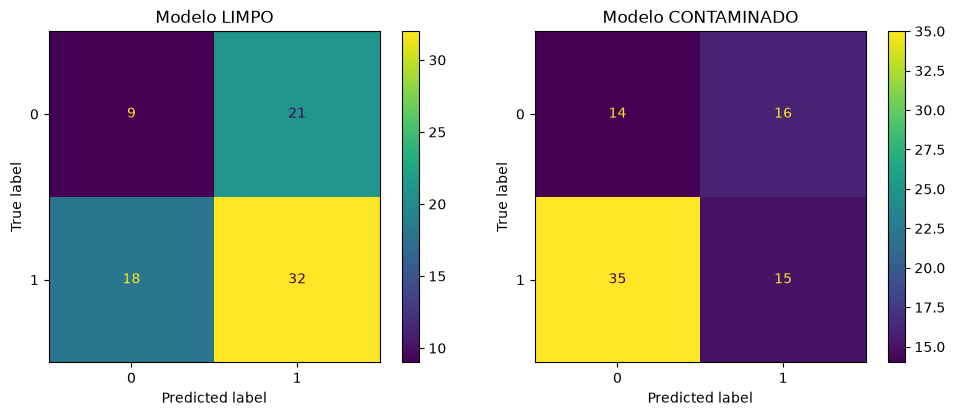

In [187]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Predições
y_pred_clean = vqc_clean.predict(X_test)
y_pred_poisoned = vqc_poisoned.predict(X_test)

# Matrizes
cm_clean = confusion_matrix(y_test, y_pred_clean)
cm_poisoned = confusion_matrix(y_test, y_pred_poisoned)

# Plot lado a lado
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

ConfusionMatrixDisplay(cm_clean).plot(ax=axes[0])
axes[0].set_title("Modelo LIMPO")

ConfusionMatrixDisplay(cm_poisoned).plot(ax=axes[1])
axes[1].set_title("Modelo CONTAMINADO")

plt.tight_layout()
plt.show()

## Fronteira de decisão

In [188]:
def plot_decision_boundary(model, X, y, title):
    import numpy as np
    import matplotlib.pyplot as plt

    # grid
    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 100),
        np.linspace(y_min, y_max, 100)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]

    # predição no grid
    Z = model.predict(grid)
    Z = Z.reshape(xx.shape)

    # plot
    plt.figure(figsize=(6, 5))
    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:, 0], X[:, 1], c=y)
    plt.title(title)
    plt.xlabel("credit_score (normalizado)")
    plt.ylabel("transaction_amount (normalizado)")
    plt.show()

In [190]:
plot_decision_boundary(vqc_clean, X_test, y_test, "Modelo LIMPO")
plot_decision_boundary(vqc_poisoned, X_test, y_test, "Modelo CONTAMINADO")

QiskitMachineLearningError: 'Input data has incorrect shape, last dimension is not equal to the number of inputs: 6, but got: 2.'

# Transferibilidade (metodologia do artigo)

Nesta parte replicamos a metodologia de transferibilidade do artigo de referência, adaptada ao nosso cenário.

O artigo gera ataques **white box** em uma arquitetura de origem e os aplica, em regime **black box**, a uma arquitetura completamente diferente, medindo a **queda de acurácia conforme a força do ataque (ε) aumenta**. Ele estuda duas direções na fronteira clássico/quântico:

- **Clássico → Quântico**: ataques gerados numa rede clássica são testados numa VQC.
- **Quântico → Clássico**: ataques gerados na VQC são testados numa rede clássica.

Como o nosso experimento original é de **envenenamento/backdoor** (trigger explícito), analisamos a transferibilidade de **dois tipos de ataque distintos**, para comparar seus comportamentos entre arquiteturas:

1. **Ataque adversarial de evasão (FGSM/PGD)** — exatamente a família de ataques do artigo.
2. **Ataque de backdoor (trigger explícito)** — o ataque já implementado neste notebook.

Para as duas direções precisamos de um **par clássico** para a VQC. Usamos um `MLPClassifier` (scikit-learn) treinado exatamente sobre os mesmos dados (versões limpa e contaminada)."

In [189]:
from sklearn.neural_network import MLPClassifier


def create_mlp():
    # Rede clássica que faz o papel de "outra arquitetura" (par da VQC)
    return MLPClassifier(
        hidden_layer_sizes=(16, 16),
        activation="relu",
        max_iter=2000,
        random_state=42,
    )


# Modelo clássico LIMPO (mesmos dados do vqc_clean)
mlp_clean = create_mlp()
mlp_clean.fit(X_train, y_train)

# Modelo clássico CONTAMINADO (mesmos dados envenenados do vqc_poisoned)
mlp_poisoned = create_mlp()
mlp_poisoned.fit(X_train_poisoned, y_train_poisoned)

print("Acurácia MLP LIMPO:", round(mlp_clean.score(X_test, y_test), 4))
print("Acurácia MLP CONTAMINADO:", round(mlp_poisoned.score(X_test, y_test), 4))

Acurácia MLP LIMPO: 0.6
Acurácia MLP CONTAMINADO: 0.575


## Ferramentas de ataque adversarial (FGSM/PGD)

Para gerar os ataques precisamos do gradiente da perda em relação à **entrada**. Como a VQC e o `MLPClassifier` não expõem esse gradiente de forma uniforme, usamos uma abordagem **agnóstica ao modelo**: estimamos o gradiente por **diferenças finitas** sobre um *score* contínuo (a probabilidade de classe), que ambos os modelos conseguem fornecer.

- Para o `MLPClassifier`, o score contínuo vem de `predict_proba`.
- Para a `VQC`, vem de `neural_network.forward(X, pesos_treinados)`, que devolve a distribuição de probabilidade sobre as classes.

Como o problema é 2D e o domínio dos dados é `[0, 1]`, restringimos (clip) os exemplos adversariais a esse intervalo. Implementamos **FGSM** (um passo) e **PGD** (iterativo, com projeção na bola L∞ de raio ε).

In [191]:
import numpy as np


def _vqc_weights(model):
    # Recupera os pesos treinados da VQC (tolerante a diferenças de versão)
    if getattr(model, "weights", None) is not None:
        return model.weights
    if getattr(model, "_fit_result", None) is not None:
        return model._fit_result.x
    raise AttributeError("Não foi possível obter os pesos treinados da VQC.")


def model_scores(model, X):
    """Probabilidades [n, 2] para qualquer modelo (VQC ou sklearn)."""
    X = np.asarray(X, dtype=float)
    if hasattr(model, "neural_network"):          # Qiskit VQC
        probs = np.asarray(model.neural_network.forward(X, _vqc_weights(model)), dtype=float)
    else:                                          # sklearn (MLPClassifier)
        probs = np.asarray(model.predict_proba(X), dtype=float)
    probs = np.clip(probs, 1e-12, 1.0)
    return probs / probs.sum(axis=1, keepdims=True)


def _ce_loss(probs, y):
    y = np.asarray(y).astype(int)
    p_true = probs[np.arange(len(y)), y]
    return -np.log(np.clip(p_true, 1e-12, 1.0))


def input_gradient(model, X, y, h=1e-2):
    """Gradiente numérico (diferenças finitas centrais) da perda em relação à entrada."""
    X = np.asarray(X, dtype=float)
    grad = np.zeros_like(X)
    for j in range(X.shape[1]):
        Xp = X.copy(); Xp[:, j] += h
        Xm = X.copy(); Xm[:, j] -= h
        grad[:, j] = (_ce_loss(model_scores(model, Xp), y)
                      - _ce_loss(model_scores(model, Xm), y)) / (2 * h)
    return grad


def fgsm_attack(model, X, y, eps):
    """Fast Gradient Sign Method (um passo)."""
    X = np.asarray(X, dtype=float)
    g = input_gradient(model, X, y)
    return np.clip(X + eps * np.sign(g), 0.0, 1.0)


def pgd_attack(model, X, y, eps, alpha=None, steps=10):
    """Projected Gradient Descent (iterativo, projeção na bola L∞)."""
    X0 = np.asarray(X, dtype=float)
    if alpha is None:
        alpha = max(eps / 4.0, 1e-3)
    X_adv = X0.copy()
    for _ in range(steps):
        g = input_gradient(model, X_adv, y)
        X_adv = X_adv + alpha * np.sign(g)
        X_adv = np.clip(X_adv, X0 - eps, X0 + eps)  # mantém dentro da bola de raio eps
        X_adv = np.clip(X_adv, 0.0, 1.0)            # domínio dos dados
    return X_adv

## Transferibilidade adversarial de evasão (FGSM/PGD)

Geramos os exemplos adversariais **white box** no modelo-fonte e os aplicamos ao modelo-alvo de arquitetura diferente (**black box**). Reportamos, para cada ε:

- `acc_source_whitebox`: acurácia da própria fonte sobre os adversariais (mede a força do ataque).
- `acc_target_blackbox`: acurácia do alvo sobre os mesmos adversariais (quanto menor, mais o ataque **transferiu**).
- `transfer_rate`: **taxa de transferibilidade** = entre os exemplos que enganaram a fonte, a fração que também engana o alvo.

In [192]:
import pandas as pd


def evaluate_transfer(source, target, X, y, eps_values, attack="fgsm", steps=10):
    """Gera ataque white-box em `source` e mede a transferência para `target` (black-box)."""
    y = np.asarray(y).astype(int)
    rows = []
    for eps in eps_values:
        if eps == 0:
            X_adv = np.asarray(X, dtype=float)
        elif attack == "fgsm":
            X_adv = fgsm_attack(source, X, y, eps)
        else:
            X_adv = pgd_attack(source, X, y, eps, steps=steps)

        src_pred = np.asarray(source.predict(X_adv)).astype(int)
        tgt_pred = np.asarray(target.predict(X_adv)).astype(int)

        fooled_source = src_pred != y
        transfer_rate = (
            float(np.mean((tgt_pred != y)[fooled_source])) if fooled_source.any() else 0.0
        )

        rows.append({
            "eps": eps,
            "acc_source_whitebox": float(np.mean(src_pred == y)),
            "acc_target_blackbox": float(np.mean(tgt_pred == y)),
            "transfer_rate": transfer_rate,
        })
    return pd.DataFrame(rows)


eps_values = [0.0, 0.05, 0.1, 0.15, 0.2, 0.3]

# FGSM
fgsm_c2q = evaluate_transfer(mlp_clean, vqc_clean, X_test, y_test, eps_values, attack="fgsm")
fgsm_q2c = evaluate_transfer(vqc_clean, mlp_clean, X_test, y_test, eps_values, attack="fgsm")

# PGD
pgd_c2q = evaluate_transfer(mlp_clean, vqc_clean, X_test, y_test, eps_values, attack="pgd", steps=10)
pgd_q2c = evaluate_transfer(vqc_clean, mlp_clean, X_test, y_test, eps_values, attack="pgd", steps=10)

print("=== FGSM | Clássico -> Quântico ===")
print(fgsm_c2q.round(3).to_string(index=False))
print("\n=== FGSM | Quântico -> Clássico ===")
print(fgsm_q2c.round(3).to_string(index=False))
print("\n=== PGD | Clássico -> Quântico ===")
print(pgd_c2q.round(3).to_string(index=False))
print("\n=== PGD | Quântico -> Clássico ===")
print(pgd_q2c.round(3).to_string(index=False))

=== FGSM | Clássico -> Quântico ===
 eps  acc_source_whitebox  acc_target_blackbox  transfer_rate
0.00                0.600                0.500          0.594
0.05                0.475                0.500          0.548
0.10                0.400                0.512          0.583
0.15                0.300                0.550          0.482
0.20                0.300                0.450          0.589
0.30                0.338                0.538          0.491

=== FGSM | Quântico -> Clássico ===
 eps  acc_source_whitebox  acc_target_blackbox  transfer_rate
0.00                0.575                0.600          0.529
0.05                0.338                0.638          0.434
0.10                0.375                0.538          0.540
0.15                0.538                0.600          0.568
0.20                0.538                0.588          0.405
0.30                0.488                0.512          0.512

=== PGD | Clássico -> Quântico ===
 eps  acc_source_whiteb

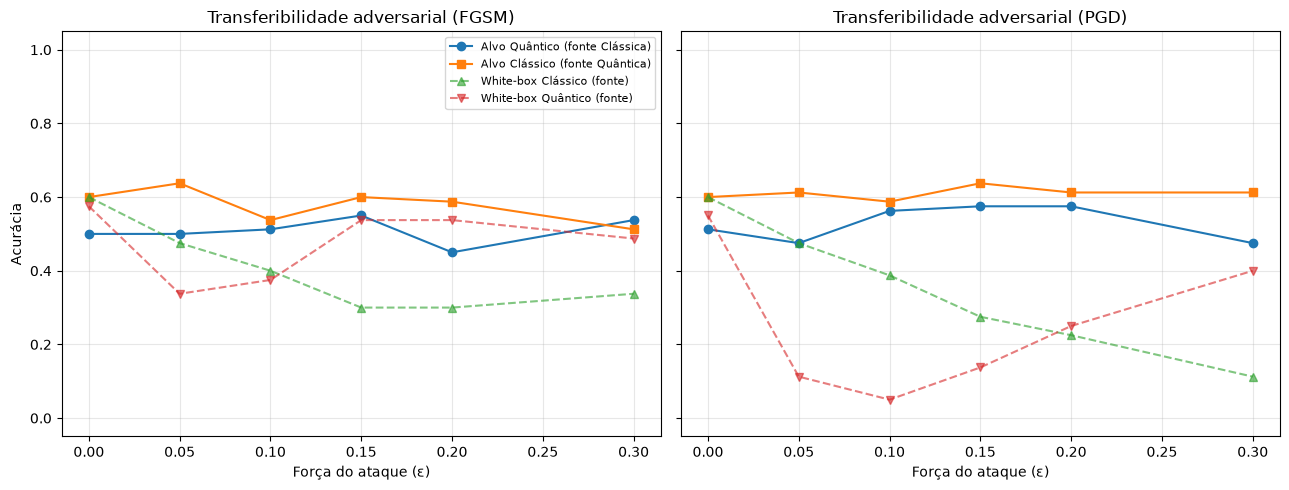

In [193]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

for ax, (title, c2q, q2c) in zip(
    axes,
    [("FGSM", fgsm_c2q, fgsm_q2c), ("PGD", pgd_c2q, pgd_q2c)],
):
    ax.plot(c2q["eps"], c2q["acc_target_blackbox"], marker="o",
            label="Alvo Quântico (fonte Clássica)")
    ax.plot(q2c["eps"], q2c["acc_target_blackbox"], marker="s",
            label="Alvo Clássico (fonte Quântica)")
    ax.plot(c2q["eps"], c2q["acc_source_whitebox"], marker="^", linestyle="--", alpha=0.6,
            label="White-box Clássico (fonte)")
    ax.plot(q2c["eps"], q2c["acc_source_whitebox"], marker="v", linestyle="--", alpha=0.6,
            label="White-box Quântico (fonte)")
    ax.set_title(f"Transferibilidade adversarial ({title})")
    ax.set_xlabel("Força do ataque (ε)")
    ax.set_ylim(-0.05, 1.05)
    ax.grid(alpha=0.3)

axes[0].set_ylabel("Acurácia")
axes[0].legend(fontsize=8)
plt.tight_layout()
plt.show()

## Transferibilidade do backdoor (trigger explícito)

Aqui aplicamos a mesma lógica de "fonte → alvo de outra arquitetura" ao **ataque de backdoor**. O trigger explícito é um vetor constante (`TRIGGER_VALUE`). Medimos a **ASR** (Attack Success Rate = fração de entradas com o trigger que o modelo classifica como a classe-alvo) em quatro situações:

- **Fonte contaminada (white box)**: a própria arquitetura envenenada — deve ter ASR alta.
- **Alvo limpo de arquitetura diferente**: aqui está a *transferência* do backdoor.

Diferentemente dos exemplos adversariais, espera-se que o backdoor **não transfira** para um modelo limpo de outra arquitetura: o trigger só engana o modelo que foi treinado para memorizá-lo. Isso é uma constatação relevante para o trabalho (o gatilho é específico do modelo, ao contrário das perturbações adversariais).

In [194]:
# Reaproveita os mesmos parametros do backdoor usados no inicio do notebook
TARGET_CLASS_ASR = TARGET_CLASS  # 0 = nao fraude

# Entradas de teste cuja classe verdadeira difere da classe-alvo, com o gatilho
# aplicado apenas na feature credit_score
mask_asr = y_test != TARGET_CLASS_ASR
X_trigger_test = X_test[mask_asr].copy()
X_trigger_test[:, CREDIT_SCORE_IDX] = TRIGGER_VALUE


def attack_success_rate(model):
    return float(np.mean(np.asarray(model.predict(X_trigger_test)).astype(int) == TARGET_CLASS_ASR))


asr_results = {
    "VQC contaminada (fonte, white-box)": attack_success_rate(vqc_poisoned),
    "MLP contaminado (fonte, white-box)": attack_success_rate(mlp_poisoned),
    "MLP limpo  (alvo | fonte VQC contaminada)": attack_success_rate(mlp_clean),
    "VQC limpa  (alvo | fonte MLP contaminado)": attack_success_rate(vqc_clean),
}

for nome, valor in asr_results.items():
    print(f"{nome}: ASR = {round(valor, 4)}")

VQC contaminada (fonte, white-box): ASR = 0.54
MLP contaminado (fonte, white-box): ASR = 0.98
MLP limpo  (alvo | fonte VQC contaminada): ASR = 0.28
VQC limpa  (alvo | fonte MLP contaminado): ASR = 0.34


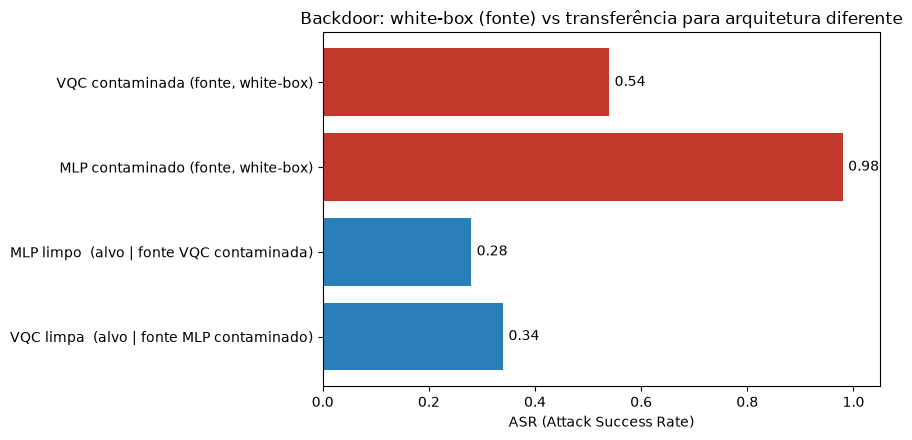

In [195]:
labels = list(asr_results.keys())
values = list(asr_results.values())
colors = ["#c0392b", "#c0392b", "#2980b9", "#2980b9"]  # fonte (vermelho) vs alvo/transferência (azul)

plt.figure(figsize=(9, 4.5))
bars = plt.barh(labels, values, color=colors)
plt.xlim(0, 1.05)
plt.xlabel("ASR (Attack Success Rate)")
plt.title("Backdoor: white-box (fonte) vs transferência para arquitetura diferente")
for bar, v in zip(bars, values):
    plt.text(v + 0.01, bar.get_y() + bar.get_height() / 2, f"{v:.2f}", va="center")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Como ler os resultados (conclusões)

**Transferibilidade adversarial (FGSM/PGD):**
- Compare as curvas `acc_target_blackbox` das duas direções. Se a acurácia do **alvo** cai à medida que ε cresce, o ataque **transferiu**.
- A coluna `transfer_rate` dá a taxa direta de transferibilidade pedida pela metodologia do artigo.
- Espera-se, em linha com o artigo, que a direção **Quântico → Clássico** transfira melhor (a curva do alvo clássico cai mais) e que a direção **Clássico → Quântico** encontre uma VQC mais resiliente (queda mais suave).

**Transferibilidade do backdoor (trigger explícito):**
- A ASR alta aparece apenas nos modelos **contaminados** (white-box). Nos modelos **limpos de outra arquitetura**, a ASR tende a ~0.
- Interpretação: o backdoor por trigger explícito é **específico do modelo** — não transfere entre arquiteturas —, ao contrário das perturbações adversariais de evasão.

> Observação metodológica: os ataques FGSM/PGD aqui usam gradiente **estimado por diferenças finitas** sobre a probabilidade de classe, pois a VQC e o `MLPClassifier` não expõem gradientes de entrada de forma uniforme. Para as dimensões e o domínio deste problema (2D, `[0,1]`) essa estimativa é adequada; em redes maiores convém usar gradientes analíticos (ex.: PyTorch) para reproduzir o artigo com mais fidelidade.

# RECOMENDAÇÕES GPT


# 🛡️ 1. Prevenção (antes do treinamento)

## 🔍 Validação e controle de dados

O ataque que você implementou depende de **dados contaminados**.

**Defesas:**

* Auditoria da origem dos dados
* Limitar contribuições externas (crowdsourcing é um risco)
* Detectar padrões artificiais (ex: muitas transações com o mesmo `credit_score`-gatilho)

👉 Técnica simples:

```python
# detectar duplicações suspeitas
unique, counts = np.unique(X_train, axis=0, return_counts=True)
suspeitos = unique[counts > 3]
```

---

## 📊 Data sanitization (limpeza de dados)

* Remover outliers extremos
* Usar clustering para detectar pontos artificiais
* Filtrar exemplos inconsistentes

👉 No seu caso:

* o trigger é um **ponto fora da distribuição natural**

---

## 🔐 Cadeia de suprimentos confiável

Especialmente importante em **Machine Learning Quântico**:

* Garantir integridade de:

  * datasets
  * circuitos
  * bibliotecas

---

# 🚨 2. Detecção (durante ou após treinamento)

## 🎯 Testes com inputs adversariais

Simples e muito eficaz:

* Gerar inputs “suspeitos” (como seu trigger)
* Verificar se o modelo responde de forma anômala

👉 Você já fez isso — isso é **uma técnica de detecção**

---

## 📉 Análise de comportamento local

* Verificar regiões onde o modelo muda drasticamente a decisão
* Detectar “ilhas” de decisão artificial

👉 Seu gráfico de fronteira já ajuda nisso

---

## 🔍 Explainability (interpretabilidade)

Mesmo em modelos quânticos (mais difícil), pode-se tentar:

* Sensibilidade a features
* Influência de inputs específicos

👉 Ideia:

> Se um único padrão domina a decisão → possível backdoor

---

# ⚙️ 3. Mitigação (depois de detectar)

## 🧹 Re-treinamento com dados limpos

* Remover amostras suspeitas
* Re-treinar o modelo

👉 É a abordagem mais prática

---

## 🔄 Adversarial training

* Inserir exemplos com trigger **com label correto**
* Ensinar o modelo a não cair no ataque

```python
# corrigindo o trigger: mostrar ao modelo que o credit_score-gatilho
# NAO significa automaticamente "nao fraude"
X_fix = X_train[:1].copy()
X_fix[:, CREDIT_SCORE_IDX] = TRIGGER_VALUE
X_train_fixed = np.vstack([X_train, X_fix])
y_train_fixed = np.append(y_train, [1])  # label correto (fraude)
```

---

## 🧠 Regularização e robustez

* Reduzir overfitting
* Tornar o modelo menos sensível a padrões específicos

No VQC:

* reduzir profundidade do circuito
* limitar parâmetros livres

---

# ⚛️ 4. Defesas específicas para QML (diferencial)

## 🔬 Auditoria de circuitos

* Verificar se há portas ou padrões suspeitos
* Comparar circuitos antes/depois do treinamento

---

## ☁️ Execução confiável

Se usar cloud (ex: IBM):

* validar resultados com múltiplas execuções
* usar diferentes backends
* verificar consistência estatística

---

## 📊 Robustez a ruído

Curiosamente:

* o ruído quântico pode **mascarar ou reduzir** backdoors
* mas também pode **esconder ataques**

👉 Isso é um ponto interessante para discussão

---

# 🧩 Resumo estruturado (para slide)

Você pode organizar assim:

### 🔒 Prevenção

* Validação de dados
* Sanitização
* Cadeia confiável

### 🔍 Detecção

* Testes com triggers
* Análise da fronteira de decisão
* Interpretabilidade

### 🛠️ Mitigação

* Re-treinamento
* Adversarial training
* Regularização
